# ECON1059 Seminar 9
***
Notes for the Seminar Series on Python Programming for Economics (ECON1059, Fall 2025)
<br><br>
Juncheng ZHANG, PhD Candidate in Economics, UNNC.
<br><br>
Research interest: Behavioral and Experimental Economics. 
<br><br>
Email: Juncheng.ZHANG@nottingham.edu.cn
***

As we are approaching the destination of our seminar series, I have to remind you once again that the exam is **paper-based and closed-book**, so I strongly recommend that you work through the **[past papers](https://moodle.nottingham.ac.uk/course/view.php?id=153042)** from the last two years and start practising writing code by hand—although I have absolutely no idea what that feels like myself (I luckily don’t have to take the exam:D)—as I believe it will feel very different from typing on a computer.

### Insertion Sort: Code

In [1]:
## Example 1 : Insertion sort code in the lecture (gonna skip)
def insertion_sort(list_):
    for i in range(1, len(list_)):
        item = list_[i]  # value at i may be overwritten
        j = i - 1 
        while list_[j] > item and j >= 0:
            list_[j + 1] = list_[j]
            j -= 1
        
        list_[j + 1] = item
        
    return list_

In [2]:
my_list = [5, 9, 11, 8, 3]
print(insertion_sort(my_list))

[3, 5, 8, 9, 11]


In [3]:
# How insertion sort works (example step, i = 3) (gonna skip)

# Start with this list:
list_ = [5, 9, 11, 8, 3]
# When i = 3, we are trying to insert the value 8
# into the already-sorted part [5, 9, 11].

item = list_[3]   # item = 8
j = 2             # start from index 2 (value 11)

# First check of the while condition: 
# j >= 0 and list_[j] > item
# j = 2, list_[2] = 11, item = 8  →  11 > 8 is True  → enter the loop
# Shift the larger element (11) one position to the right:
list_[j + 1] = list_[j]        # list_ becomes [5, 9, 11, 11, 3]
j -= 1                         # j = 1

# Second check of the while condition:
# j >= 0 and list_[j] > item
# j = 1, list_[1] = 9, item = 8  →  9 > 8 is True  → enter the loop again
# Shift the larger element (9) one position to the right:
list_[j + 1] = list_[j]        # list_ becomes [5, 9, 9, 11, 3]
j -= 1                         # j = 0

# Third check of the while condition:
# j >= 0 and list_[j] > item
# j = 0, list_[0] = 5, item = 8  →  5 > 8 is False  → stop shifting

# Now we use the saved variable `item` to put 8 back
# into the correct position:
list_[j + 1] = item            # list_ becomes [5, 8, 9, 11, 3]


### Time Complexity (Big O) of Sort

* Order of Growth tells us how fast a program’s running time increases as the input size gets larger.
* It is a way of classifying how the number of basic operations grows with the input size \(n\).

In this topic, we define \(T(n)\) as the **number of comparisons** when sorting a list of size \(n\).

- Each time we check something like `if a > b`, we count **one basic operation**.
- We then use Big-O notation to describe how \(T(n)\) grows as \(n\) becomes large.

So for sorting algorithms in this topic: **basic operation = one comparison.**




## Bubble Sort
* Derive the Time Complexity of Bubble Sort (for the Worst-Case).

* The answer to this problem is actually quite simple (once you start from the "correct" starting point). Suppose the list is perfectly sorted in reverse, e.g. $[5, 4, 3, 2, 1]$.

* Round 1: the first item, $5$, will fully travel to the back, without any other item being sorted.

* Round 2: the new first item, $4$, will then travel to its correct position without any other item being sorted.

* (With our implementation of bubble sort), we will therefore loop $n$ times, with $n-1$ comparisons each time.
* As a result, we have $T(n) = n^2 - n$ comparisons and a time complexity of $O(n^2)$.

**Follow up question:** based on these solutions, can you think of ways to improve the bubble sort algorithm to improve its performance?

### Bubble Sort: Code

In [4]:
## Example 2 : Bubble sort code in the lecture 
def bubble_sort(list_):
    not_sorted = True
    number_of_swaps = 0

    while not_sorted:
        for i in range(len(list_)-1):
            if list_[i] > list_[i+1]:
                # Swap adjacent items
                temp = list_[i+1]
                list_[i+1] = list_[i]
                list_[i] = temp
                
                number_of_swaps += 1
        
        if number_of_swaps == 0:
        # This means that even if the list was already sorted,
        # we still had to run one full pass of the basic algorithm to check.        
            not_sorted = False
        else:
            number_of_swaps = 0
            
    return list_

In [5]:
my_list = [5, 9, 11, 8, 3]
print(bubble_sort(my_list))

[3, 5, 8, 9, 11]


In [6]:
# How bubble sort works (example step)
list_ = [5, 4, 3, 2, 1]
num_comparisons = 0

# This simulates ONE full pass of the inner for-loop in bubble_sort:
for i in range(len(list_) - 1):   # i = 0, 1, 2, 3
    # Each check "list_[i] > list_[i+1]" counts as ONE comparison
    num_comparisons += 1
    if list_[i] > list_[i + 1]:
        # Swap adjacent items
        temp = list_[i + 1]
        list_[i + 1] = list_[i]
        list_[i] = temp
    print(f"After i = {i}: {list_}")

print("T(1) =", num_comparisons, "comparisons in this pass")


After i = 0: [4, 5, 3, 2, 1]
After i = 1: [4, 3, 5, 2, 1]
After i = 2: [4, 3, 2, 5, 1]
After i = 3: [4, 3, 2, 1, 5]
T(1) = 4 comparisons in this pass


In [7]:
## Why we need temp
 
list_[i]    = 5
list_[i+1]  = 3
 
# If we try to swap without temp, like this:
 
list_[i] = list_[i+1]     # list_[i] becomes 3
list_[i+1] = list_[i]     # list_[i+1] also becomes 3  -> [3, 3, ...]
 
# The 5 is lost forever, because it was overwritten during the first assignment.

In [8]:
# Improve the code (gonna skip)
import copy

def bubble_sort_imp(list_input):
    mylist = list_input.copy()
    for i in range(len(mylist) - 1):
        swapped = False
        for j in range(len(mylist) - i - 1):
            if mylist[j] > mylist[j + 1]:
                mylist[j], mylist[j + 1] = mylist[j + 1], mylist[j]
                swapped = True
        if not swapped:
            break
    
    return mylist

In [9]:
# How improved bubble sort works (example step: two passes) (gonna skip)

list_ = [5, 4, 3, 2, 1]
mylist = list_.copy()
n = len(mylist)

print("Initial list:", mylist)
print()

total_comparisons = 0  # total number of comparisons so far

# We only simulate the first TWO passes: i = 0 and i = 1
for i in range(2):  # i = 0, 1  → passes k = 1, 2
    swapped = False
    comparisons_this_pass = 0  # T(k): comparisons in this pass
    print(f"Pass {i} (k = {i+1}), start:", mylist)
    
    # Inner loop: notice the range is (n - i - 1)
    for j in range(n - i - 1):
        # Each check mylist[j] > mylist[j+1] counts as one comparison
        comparisons_this_pass += 1
        if mylist[j] > mylist[j + 1]:
            mylist[j], mylist[j + 1] = mylist[j + 1], mylist[j]
            swapped = True
        print(f"  After j = {j}: {mylist}")
    
    total_comparisons += comparisons_this_pass
    print(f"Pass {i} (k = {i+1}), end: {mylist}, swapped = {swapped}")
    print(f"T({i+1}) = {comparisons_this_pass} comparisons in this pass")
    print()

print("List after two passes:", mylist)
print("Total comparisons in these two passes:", total_comparisons)

# Theoretical general form (worst case):
print("In general (worst case):")
print("T(n) = (n - 1) + (n - 2) + ... + 1 = n * (n - 1) / 2")


Initial list: [5, 4, 3, 2, 1]

Pass 0 (k = 1), start: [5, 4, 3, 2, 1]
  After j = 0: [4, 5, 3, 2, 1]
  After j = 1: [4, 3, 5, 2, 1]
  After j = 2: [4, 3, 2, 5, 1]
  After j = 3: [4, 3, 2, 1, 5]
Pass 0 (k = 1), end: [4, 3, 2, 1, 5], swapped = True
T(1) = 4 comparisons in this pass

Pass 1 (k = 2), start: [4, 3, 2, 1, 5]
  After j = 0: [3, 4, 2, 1, 5]
  After j = 1: [3, 2, 4, 1, 5]
  After j = 2: [3, 2, 1, 4, 5]
Pass 1 (k = 2), end: [3, 2, 1, 4, 5], swapped = True
T(2) = 3 comparisons in this pass

List after two passes: [3, 2, 1, 4, 5]
Total comparisons in these two passes: 7
In general (worst case):
T(n) = (n - 1) + (n - 2) + ... + 1 = n * (n - 1) / 2


In [10]:
## Example 3 : Merge sort code in the lecture
def merge_sort(list_):
    width = 1  # width of the sub-lists to sort 
    
    while width < len(list_):
        # Iterate over each pair of sub-lists.
        # Starting with sub-lists of size 1, followed by 2, 4, etc.
        for i in range(0, len(list_), 2*width):
            # Pick two sub-lists
            left = list_[i:i+width]  # list[start:stop] don't includes stop
            right = list_[i+width:i+2*width]
            merged_list = []

            # Sort and combine elements
            i_left = 0
            i_right = 0
            while i_left < len(left) and i_right < len(right):
                if left[i_left] < right[i_right]:
                    merged_list.append(left[i_left])
                    i_left += 1
                else:
                    merged_list.append(right[i_right])
                    i_right += 1
            # Append any remaining elements (in one of the two)
            merged_list.extend(left[i_left:])
            merged_list.extend(right[i_right:])

            # Place merged array back into original array
            list_[i:i+len(merged_list)] = merged_list
        width *= 2
    
    return list_

In [11]:
my_list = [5, 9, 11, 8, 3]
print(bubble_sort(my_list))

[3, 5, 8, 9, 11]


In [12]:
def demo_merge_sort_steps():
    # Initial list (you can change this if you like)
    list_ = [5, 9, 11, 8, 3]
    print("Initial list:", list_)
    
    width = 1  # width of the sub-lists to merge
    
    # Outer loop: increase width each time (1, 2, 4, ...)
    while width < len(list_):
        print("\n====================================")
        print(f"WHILE LOOP: width = {width}")
        print("Current list:", list_)
        
        # Iterate over pairs of sub-lists of size `width`
        i = 0
        while i < len(list_):
            print("\n--- New pair starting at i =", i, "---")
            
            # Take two slices: left and right
            left = list_[i : i + width]
            right = list_[i + width : i + 2 * width]
            
            print("  left :", left)
            print("  right:", right)
            
            merged_list = []
            i_left = 0
            i_right = 0
            
            # Merge left and right while both have elements
            while i_left < len(left) and i_right < len(right):
                print(
                    f"    Compare left[{i_left}] = {left[i_left]} "
                    f"and right[{i_right}] = {right[i_right]}"
                )
                if left[i_left] < right[i_right]:
                    merged_list.append(left[i_left])
                    print(f"      → take {left[i_left]} from left → merged_list = {merged_list}")
                    i_left += 1
                else:
                    merged_list.append(right[i_right])
                    print(f"      → take {right[i_right]} from right → merged_list = {merged_list}")
                    i_right += 1
            
            # One of left/right is now exhausted; append the rest
            if i_left < len(left):
                print(f"    Left has remaining elements {left[i_left:]}, append them")
            if i_right < len(right):
                print(f"    Right has remaining elements {right[i_right:]}, append them")
            
            merged_list.extend(left[i_left:])
            merged_list.extend(right[i_right:])
            
            print("  merged_list =", merged_list)
            
            # Write merged_list back into the original list
            list_[i : i + len(merged_list)] = merged_list
            print("  list_ after writing back:", list_)
            
            # Move to the next pair of sub-lists
            i += 2 * width
        
        # After processing all pairs for this width, double the width
        print("\nEnd of this while-iteration, list_ =", list_)
        width *= 2
    
    print("\nFinal sorted list:", list_)


# Run the step-by-step demo
demo_merge_sort_steps()


Initial list: [5, 9, 11, 8, 3]

WHILE LOOP: width = 1
Current list: [5, 9, 11, 8, 3]

--- New pair starting at i = 0 ---
  left : [5]
  right: [9]
    Compare left[0] = 5 and right[0] = 9
      → take 5 from left → merged_list = [5]
    Right has remaining elements [9], append them
  merged_list = [5, 9]
  list_ after writing back: [5, 9, 11, 8, 3]

--- New pair starting at i = 2 ---
  left : [11]
  right: [8]
    Compare left[0] = 11 and right[0] = 8
      → take 8 from right → merged_list = [8]
    Left has remaining elements [11], append them
  merged_list = [8, 11]
  list_ after writing back: [5, 9, 8, 11, 3]

--- New pair starting at i = 4 ---
  left : [3]
  right: []
    Left has remaining elements [3], append them
  merged_list = [3]
  list_ after writing back: [5, 9, 8, 11, 3]

End of this while-iteration, list_ = [5, 9, 8, 11, 3]

WHILE LOOP: width = 2
Current list: [5, 9, 8, 11, 3]

--- New pair starting at i = 0 ---
  left : [5, 9]
  right: [8, 11]
    Compare left[0] = 5 an

**The instructor is doing two things** (It is not like the human language, btw :/ ):
1. For each `width`, count how many comparisons are done at that level.
2. Then count how many different `width` values there are (i.e. how many `while`-loop levels).


## Time Complexity of Merge Sort (hard)
1. Preliminary: How many comparisons are needed to create a sorted lists from two sorted list of equal length $m$ (based on the sorting algorithm in Merge Sort). Solve for the Worst Case.
2. Derive the Time Complexity of Merge Sort for the Worst-Case Scenario. 

### Combing Sorted Lists into a Sorted List.
**Best Case:** the last element of one list is smaller than the first element of the other list. This will require $m$ comparisons only for a combined list of size $2m$

Similarly, exhausting one list early means that we only perform $2m - k$ comparisons, with $k$ being the remaining elements in the non-exhausted list.

**Worst Case:** Neither list is exhausted until 1 element from each list is remaining. There are many versions that will result in this case. One of them is when the two lists $x=[x_0, x_1, \ldots, x_{m-1}]$ and $y=[y_0, y_1, \ldots, y_{m-1}]$ satisfy $x_i < y_i < x_{i+1} < y_{i+1}$ for all $i \in \{0,\ldots m-2\}$.
For this case, we will require $S(m) = 2m - 1$ comparisons.
<br>
(I use some arbitrary function called $S(m)$ here to refer to the comparisons, which will make the next slide a bit better to understand)

2. Derive the Time Complexity of Merge Sort for the Worst-Case Scenario.

If we disregard any splitting of the list into `left` and `right` and merging the sorted list back onto the full list - which I do - then the preliminary analysis covers almost the whole code block inside merge_sort. What remains are two loops:
`while width < len(list_)` and the `for i in range(0, len(list_), 2*width)` within.

Let's cover both of these at the same time, increasing the width. 
* For `width`=1, we combine two sublists of size 1, n/2 times (into a sorted list) $\to$ $S(1)\cdot n/2 = n/2$

* For `width`=2, we combine two sublists of size 2, n/4 times $\to$ $S(2)\cdot n/4 = 3n/4$

* For `width`=4, we combine two sublists of size 4, n/8 times $\to$ $S(4)\cdot n/8 = 7n/8$

* For any `width`=k, we combine two sublists of size k, n/(2k) times $\to$ $(2k-1)\cdot n/(2k) = (1 - (2k)^{-1})\cdot n$

* For `width`=n/2, we combine two sublists of size n/2, 1 time $\to$ $S(n/2)\cdot 2 = 2(n/2)-1  = n - 1$

* Instead of computing an exact formula for the above, we simply observe that the number of comparisons for potential widths is less than $n$.
* Next, we need to figure out how many loops our algorithm runs for a given n. Once we know that, we can know that it's of order $n \cdot$ number of loops

* Notice that the width doubles every round, which strongly limits to number of loops our algorithm runs as $n$ increases.
* Just like in binary search, we express $n = 2^j$, or $j = \log_2(n)$. $j$ captures exactly the number of loops needed.
    * To see that this is true, note: $j=1$ is $n=2$ and a "final" `width` is 1; $j=2$ is $n=4$ and a final `with` of 4, which is reached after two loops.

* In conclusion, Merge Sort is of order $O(n \log n)$, much better than $n^2$!

## Estimating Compute Time for Bubble and Merge Sort
Using the time and matplotlib module, graph the compute time for Bubble and Merge Sort when sorting a list of size $n \in \{10^2, 10^3, 10^4, 10^5\}$ comprised of random elements.
<br>
<br>
**A note on the implementation:** every time you run any of the two sorting mechanisms create a new, unsorted list (we will discuss why in the seminar).

<details>
<summary>Suggestions for coding this question:</summary>
    Start with the two smallest list sizes first, i.e., $10^2$ and $10^3$ and get it working first.
</details> 
    
<details>
<summary>Hint for Graph</summary>
You may want to consider rescaling the X and/or the Y-Axis. You can automatically rescale your axes using ax.set_xscale('log), ax.set_yscale('log'). For more details and other rescaling options, see https://matplotlib.org/stable/api/scale_api.html#builtin-scales
</details> 

In [13]:
def bubble_sort(list_):
    not_sorted = True
    number_of_swaps = 0

    while not_sorted:
        for i in range(len(list_)-1):
            if list_[i] > list_[i+1]:
                temp = list_[i+1]
                list_[i+1] = list_[i]
                list_[i] = temp
                number_of_swaps += 1
                
        if number_of_swaps == 0:
            not_sorted = False
        else:
            number_of_swaps = 0  
            
    return list_

In [14]:
def merge_sort(list_):
    width = 1
    
    while width < len(list_):
        for i in range(0, len(list_), 2*width):
            left = list_[i:i+width] 
            right = list_[i+width:i+2*width]
            merged_list = []

            i_left = 0
            i_right = 0
            while i_left < len(left) and i_right < len(right):
                if left[i_left] < right[i_right]:
                    merged_list.append(left[i_left])
                    i_left += 1
                else:
                    merged_list.append(right[i_right])
                    i_right += 1

            merged_list.extend(left[i_left:])
            merged_list.extend(right[i_right:])

            list_[i:i+len(merged_list)] = merged_list
        width *= 2
    
    return list_

In [15]:
import time
import random

random.seed(5500550055)
num_elements_li = [10, 100, 1000, 10000]  # Don't try 1 000 000. It takes forever
compute_times_bubble = []
compute_times_merge = []

for list_size in num_elements_li:
    li = [random.random() for _ in range(list_size)]
    time_start = time.time()
    bubble_sort(li)
    compute_times_bubble.append(time.time() - time_start)

    # See comment below of why we need to create a new list.
    li = [random.random() for _ in range(list_size)]
    time_start = time.time()
    merge_sort(li)
    compute_times_merge.append(time.time() - time_start)

print(f"Time Needed Bubble Sort: {compute_times_bubble}.\n")
print(f"Time Needed Merge Sort: {compute_times_merge}")

Time Needed Bubble Sort: [1.5020370483398438e-05, 0.0006520748138427734, 0.047116756439208984, 3.163100004196167].

Time Needed Merge Sort: [2.002716064453125e-05, 0.00015115737915039062, 0.0008161067962646484, 0.008765935897827148]


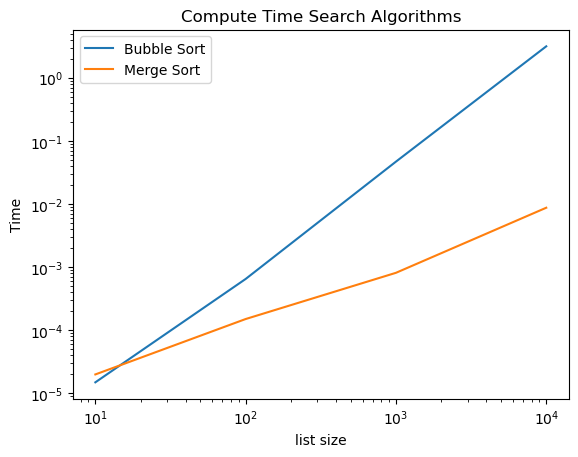

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(num_elements_li, compute_times_bubble, label="Bubble Sort")
ax.plot(num_elements_li, compute_times_merge, label="Merge Sort")
ax.set_xlabel("list size")
ax.set_ylabel("Time")

# At the very least, you should rescale the y-axis.
# Try the alternatives to see how the graphs look otherwise
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_title("Compute Time Search Algorithms")
ax.legend()
plt.show()

Observaton: Again, the more efficient algorithm for very small lists performs worse (like in last week's homework).

### Local Scopes when Passing in Lists.
* Why is it necessary to create a new list?
* This gets us into a topic we didn't cover in great detail this year and relates to how Python manages memory of different types of objects, especially data containers 
* The short answer is that the list that is passed into either of the two sorting mechanisms actually gets sorted as well, breaking our usual local vs. global scope idea (check that!)
* On the next slide(s), we discuss more generic examples

A standard local scope example that we all are familiar with

In [17]:
def func_1(x):
    x = 5*x  # local variable
    return x

z = 5
result = func_1(z)
print(f"z={z}, result={result}")  

z=5, result=25


* z remains the same. 
* Indeed, no-one ever would expect it to be affected

A suprising, not-so-local-scope-example

In [18]:
def swap_first_two_elements(numbers):
    temp = numbers[0]
    numbers[0] = numbers[1]  
    numbers[1] = temp
    return numbers

my_list = [0, 1, 2]
modified_list = swap_first_two_elements(my_list)
print(f"my_list={my_list}, modified list={modified_list}")

my_list=[1, 0, 2], modified list=[1, 0, 2]


* The original list is modified too!

### Memory and Mutable Data Types
* Lists (and similar data containers) are mutable; (re-) assignment of *any element within* does not create a new object in memory (e.g., an adjusted copy of the original).

* In the context of functions (note: this "problem" is not just limited to functions), the argument `numbers` creates a reference to the list object stored in memory for `my_list` (which is memory efficient). This has the consequence that changes to numbers inside the function also affects the `my_list`.
* For more details (entirely optional, see the lecture on Memory, which is available on Moodle)

* **What you should remember:** when working on datacontainers (that are passed) inside functions, you should create a local copy with `my_list.copy()` whenever you modify elements inside those containers.
* `.copy()` creates a clean copy of the outermost list (often called shallow copy), which is a separate object from the original list.
* For multi-dimensional lists, `import copy` and use `copy.deepcopy(my_list)` 

In [19]:
import copy
def swap_first_two_elements_2(numbers):
    numbers = numbers.copy()  # Assigning to a different name also works
    temp = numbers[0]
    numbers[0] = numbers[1]  
    numbers[1] = temp
    return numbers
    
my_list = [0, 1, 2]
modified_list = swap_first_two_elements_2(my_list)
print(f"my_list={my_list}, modified list={modified_list}")

my_list=[0, 1, 2], modified list=[1, 0, 2]


**Follow up Exercise:** update our sorting algorithms with regards to the list-problem discussed above. Also, verify that problem with the old sort functions exists and check that it is no longer present with your updated versions.

**Another follow up Exercise:** 
* You can (and maybe even should) consider estimating compute times for each sorting algorithm separately, and write slightly more generalizable code.
* With two functions, the current code is honestly good enough, meaning it's not worth writing something more complex. Nevertheless, can you think of a better solution? See appendix for a more general approach.

## Hangman
For the last official homework, rewrite our (or your) previous version of the Hangman Game into a class, keeping in mind everything you have learned in our course. Enjoy!
<br>
Note: it's usually a good idea to not start the game with the initialization of the class, but instead, with a method called start (that contains your main game loop)

* Note to students. Comments with "MR" are for teaching purposes. I wouldnt add them in a real class. I was also lazy and did not include docstrings for functions (but you should).
* As always **solutions are better read in notebook or hmtl** 

In [ ]:
import random
import os

class Hangman:
    """A simple text-console hangman game.

    Standard implementation of the hangman game with up to 6 guesses that may be wrong, 
    until main character is hung.
    To increase the difficulty, adjust class attribute 'total_misses_allowed'
    
    Attributes:
        filepath_secret_words: path to file that stores secret word. Requires words to be separated by lines in a .txt file
        secret_word: the word that must be guessed during a game
        total_misses: misses guesses in current game
        guessed_correctly: a list that tracks whether letter i has been guessed already
        past_guesses: a list that tracks all guesses that were already made
        is_play: a boolean that tracks if the game is currently running    
    """
    
    total_misses_allowed = 6  # adjust for change in difficulty. 
    # MR: hangman has a fixed difficulty, that is independent of the instance. 
    # Can be defined here or in the __init__
    
    def __init__(self, filepath_secret_words='files/topic_6/hangman_words.txt'):
        self.filepath_secret_words = filepath_secret_words  

        # Game state variables; since this is a small program, 
        # I think it's nicer to declare them already so it's clear what
        # attributes we deal with in the functions below. 
        # Most are set/loaded in start_game()
        self.secret_word = None  
        self.total_misses = 0
        self.guessed_correctly = []
        self.past_guesses = []
        self.is_playing = False

    @staticmethod    
    def load_secret_word(filepath):
        # MR: somehow feels more correct as a staticmethod with paths being passed in
        # could also refer to self.filepath_secret_words directly 
        f = open(filepath)
        list_words = f.readlines()
        f.close()
        word = random.choice(list_words).rstrip('\n')
        return word.lower() # always stick to lower-case words

    def print_secret_word_guessed(self): 
        to_print = ""    
        for letter, guess in zip(self.secret_word, self.guessed_correctly):   
            if guess == True:
                to_print += letter + " "
            else:
                to_print += "_ "
        print(to_print)
    
    def check_guess(self, guess):  
        guess_is_correct = False
        for i, secret_word_char in enumerate(self.secret_word):   
            if guess == secret_word_char:
                guess_is_correct = True  # Sets guess correct if (at least one) is correct
                self.guessed_correctly[i] = True  # No need to set false as always stated out as false
            
        if guess_is_correct:
            print("Correct!\n\n\n")
        else:
            print(f"Incorrect!\n\n\n")
        
        return guess_is_correct      

    def update_game_state(self, guess_is_correct, guess):
        if not guess_is_correct:
            self.total_misses += 1
            self.past_guesses.append(guess)
            if self.total_misses == self.total_misses_allowed:   
                # MR: having the graphical-user-interfact be sorted out in update_game_state is not ideal
                # Why? A function should do one thing only.
                # A cleaner way is to track won/lost/playing; with a variable that can take only take one of these values.
                # Then have the game over / you win screen determined in a seperate method. 
                print("--- Game Over ---")  
                self.is_playing = False
        else:
            has_won = 1
            for correct_letter_guessed in self.guessed_correctly:
                has_won *= correct_letter_guessed  # False = 0, True = 1. Has won if all are 1.
            if has_won:
                self.print_secret_word_guessed()  # Show final word; also not ideal to do that here.
                print("!!! You win !!!")
                self.is_playing = False

    def game_loop(self):
        while self.is_playing:
            self.print_secret_word_guessed()  
            print(f"Already guessed: {self.past_guesses}.\n") 
            
            guess = input(f"Please make a guess ({self.total_misses_allowed - self.total_misses} mistakes left):\n")
            guess = guess.lower()
            guess_is_correct =  self.check_guess(guess) 
            self.update_game_state(guess_is_correct, guess)

    def start_game(self):
        self.secret_word = self.load_secret_word(self.filepath_secret_words)
        self.guessed_correctly = len(self.secret_word)*[False] 
        self.is_playing = True
        #print(my_hangman.secret_word)  # You can comment this in for debugging. always consider making cheating part of your code
        # Aside: IDEs let you cheat also via Debug Mode, giving you full access to all variables.
        self.game_loop()

In [ ]:
my_hangman_game = Hangman()
my_hangman_game.start_game()

### Notes on above implementation.
* This implementation works perfectly for our purpose
* For a gui implemntation (or any use of the game where the game is started more than once), the start_game() should probably also reset all game specific variables such as missed guesses, past_guesses, etc.

### Other things to try
* Add a timer to your Hangman game and measure how long it takes people to complete it.
* A more advanced version of that would then save this time to a file. Essentially, this can be turned into a "High-scores" or "Best-attempts" table. Here, you may want to think about how you can implement a "Top 5 Fastest Answers" solution

## Appendix

**Another follow up Exercise:** 
* You can (and maybe even should) consider estimating compute times for each sorting algorithm separately, and write slightly more generalizable code.
* With two functions, the current code is honestly good enough, meaning it's not worth writing something more complex. Nevertheless, can you think of a better solution? See appendix for a more general approach.

**Answer:** let's write a simple function that returns the compute time for any generic algorithm that takes in a list of numbers!

In [20]:
def get_compute_time_sorting_algorithm(algorithm, numbers):
    time_start = time.time()
    algorithm(numbers)  # Python is beautiful! Notice what happens here!
    return time.time() - time_start

This allows us to simply our problem to:

In [21]:
import time
import random

random.seed(5500550055)
num_elements_li = [10, 100, 1000, 10000]

list_algorithms = [bubble_sort, merge_sort]
compute_times=[[],[]]

for list_size in num_elements_li:
    li = [random.random() for _ in range(list_size)]
    
    for i, algorithm in enumerate(list_algorithms):    
        total_time = get_compute_time_sorting_algorithm(algorithm, li.copy())
        compute_times[i].append(total_time)

print("Computation complete.")

Computation complete.


In [22]:
print(f"Time Needed Bubble Sort: {compute_times[0]}.\n")
print(f"Time Needed Merge Sort: {compute_times[1]}")

Time Needed Bubble Sort: [1.5974044799804688e-05, 0.0008120536804199219, 0.0380098819732666, 3.5289859771728516].

Time Needed Merge Sort: [1.9788742065429688e-05, 0.00018024444580078125, 0.0006620883941650391, 0.009280920028686523]


* Note: even with a fixed seed, running the same code will  always yield slightly different times. Hence the time estimates here will not be exactly the same as in our previous implementation.